# 04 — Evaluación experta del sistema GraphRAG Holmes

Esta evaluación va más allá de las métricas RAGAS básicas. El objetivo es tratar el sistema como una caja **parcialmente** transparente y auditarlo de forma sistemática desde varios ángulos:

| Dimensión | Pregunta clave |
|-----------|---------------|
| **Router** | ¿Elige la herramienta correcta para cada tipo de pregunta? |
| **RAGAS por categoría** | ¿Dónde funciona bien y dónde falla? |
| **Adversarialidad** | ¿Alucina cuando no debería saber la respuesta? |
| **Consistencia** | ¿Responde igual si reformulo la misma pregunta? |
| **Latencia** | ¿Cuánto cuesta (en tiempo) cada tipo de consulta? |
| **Taxonomía de fallos** | ¿Qué tipo de error es más frecuente? |

**Prerrequisito:** Ejecutar `01_ingestion_demo.ipynb` para cargar los datos en Neo4j.

## 1. Configuración

In [1]:
import sys
sys.path.append('..')

import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from tqdm import tqdm

from graphrag.graph.neo4j_manager import Neo4jManager
from graphrag.agents import AgenticRAG
from graphrag.evaluation import RAGEvaluator

pd.set_option('display.max_colwidth', 70)
pd.set_option('display.float_format', '{:.3f}'.format)

neo4j     = Neo4jManager()
rag       = AgenticRAG(neo4j)
evaluator = RAGEvaluator(rag, neo4j)

CATEGORY_COLORS = {
    'factual':     '#4C72B0',
    'descriptive': '#DD8452',
    'structural':  '#55A868',
    'adversarial': '#C44E52',
    'robustness':  '#8172B2',
}

print('Sistema listo.')
print(f'Grafo: {neo4j.get_stats()}')

Sistema listo.
Grafo: {'Event': 412, 'Deduction': 323, 'Object': 269, 'Chunk': 200, 'Scene': 185, 'Location': 85, 'Character': 73, 'Crime': 19, 'Story': 6}


## 2. Suite de preguntas clasificadas

Las preguntas se distribuyen en **5 categorías** que representan casos de uso reales:

| Categoría | Descripción | Herramienta esperada |
|-----------|-------------|---------------------|
| **Factual** | Respuesta exacta recuperable del grafo | `text2cypher` |
| **Descriptive** | Comprensión narrativa del texto | `vector_search` / `hybrid_search` |
| **Structural** | Traversal multi-salto del grafo | `text2cypher` |
| **Adversarial** | Respuesta NO está en la base de conocimiento | abstención |
| **Robustness** | Referencias indirectas, bilingüe, sinónimos | varía |

In [2]:
BENCHMARK = [
    # ── FACTUAL ──────────────────────────────────────────────────────────
    {
        'id': 'F1', 'category': 'factual',
        'question': 'How many stories are in the graph?',
        'expected_tool': 'text2cypher',
        'cypher': "MATCH (s:Story) WITH count(s) AS n RETURN 'There are ' + toString(n) + ' stories.' AS ground_truth",
    },
    {
        'id': 'F2', 'category': 'factual',
        'question': 'Which characters appear in more than one story?',
        'expected_tool': 'text2cypher',
        'cypher': 'MATCH (c:Character)-[:APPEARS_IN]->(s:Story) WITH c, count(s) AS n WHERE n > 1 RETURN c.name AS ground_truth ORDER BY n DESC',
    },
    {
        'id': 'F3', 'category': 'factual',
        'question': 'How many deductions does Holmes make in The Adventure of the Speckled Band?',
        'expected_tool': 'text2cypher',
        'cypher': "MATCH (d:Deduction) WHERE toLower(d.story_title) CONTAINS 'speckled band' WITH d.story_title AS title, count(d) AS n RETURN title + ' contains ' + toString(n) + ' deductions.' AS ground_truth",
    },
    {
        'id': 'F4', 'category': 'factual',
        'question': 'Which story has the most deductions?',
        'expected_tool': 'text2cypher',
        'cypher': "MATCH (d:Deduction) WITH d.story_title AS title, count(d) AS n ORDER BY n DESC RETURN title + ' has ' + toString(n) + ' deductions' AS ground_truth",
    },
    # ── DESCRIPTIVE ───────────────────────────────────────────────────────
    {
        'id': 'D1', 'category': 'descriptive',
        'question': 'How does Holmes disguise himself in A Scandal in Bohemia?',
        'expected_tool': 'vector_search',
        'cypher': "RETURN 'Holmes disguises himself as a drunken groom and later as a Nonconformist clergyman in A Scandal in Bohemia.' AS ground_truth",
    },
    {
        'id': 'D2', 'category': 'descriptive',
        'question': 'Describe the atmosphere at the Reichenbach Falls.',
        'expected_tool': 'hybrid_search',   # fix: sistema eligió hybrid_search correctamente
        'cypher': "RETURN 'The Reichenbach Falls is a dreadful place with a tremendous abyss. The torrent, swollen with melting snow, plunges into the abyss from which spray rises like smoke, with the constant swirl and clamour of roaring water.' AS ground_truth",
    },
    {
        'id': 'D3', 'category': 'descriptive',
        'question': 'What role does the cipher play in The Adventure of the Dancing Men?',
        'expected_tool': 'hybrid_search',
        'cypher': "RETURN 'The dancing men cipher is the central mystery: Holmes deciphers it by frequency analysis, uncovering a threat to Elsie Cubitt from her criminal past in America.' AS ground_truth",
    },
    {
        'id': 'D4', 'category': 'descriptive',
        'question': 'How does Holmes use disguise as an investigative method?',
        'expected_tool': 'hybrid_search',
        'cypher': "RETURN 'Holmes uses disguise extensively across stories, adopting personas such as a drunken groom, a Nonconformist clergyman, and an old bookseller to gather information without being recognised.' AS ground_truth",
    },
    # ── STRUCTURAL ────────────────────────────────────────────────────────
    {
        'id': 'S1', 'category': 'structural',
        'question': 'Which characters know Holmes AND appear in more than one story?',
        'expected_tool': 'text2cypher',
        'cypher': "MATCH (c:Character)-[:KNOWS]->(h:Character {name: 'Sherlock Holmes'}), (c)-[:APPEARS_IN]->(s:Story) WITH c, count(DISTINCT s) AS n WHERE n > 1 RETURN c.name + ' knows Holmes and appears in ' + toString(n) + ' stories' AS ground_truth ORDER BY n DESC",
    },
    {
        'id': 'S2', 'category': 'structural',
        'question': 'What objects does Sherlock Holmes use across all stories?',
        'expected_tool': 'text2cypher',
        'cypher': "MATCH (c:Character {name: 'Sherlock Holmes'})-[:USES]->(o:Object) RETURN DISTINCT o.name AS ground_truth ORDER BY o.name",
    },
    {
        'id': 'S3', 'category': 'structural',
        'question': 'In which stories do crimes of type murder appear?',
        'expected_tool': 'text2cypher',
        # fix: RETURN DISTINCT + ORDER BY sobre variable pre-WITH daba SyntaxError en Neo4j 5
        'cypher': "MATCH (cr:Crime) WHERE toLower(cr.type) CONTAINS 'murder' WITH DISTINCT cr.story_title AS title RETURN title + ' contains murder crimes' AS ground_truth ORDER BY title",
    },
    # ── ADVERSARIAL ───────────────────────────────────────────────────────
    {
        'id': 'A1', 'category': 'adversarial',
        'question': 'What happens in The Adventure of the Blue Carbuncle?',
        'expected_tool': 'vector_search',
        'cypher': "RETURN 'Esta información no se encuentra en la base de conocimiento.' AS ground_truth",
    },
    {
        'id': 'A2', 'category': 'factual',   # fix: el año de nacimiento sí está en el grafo → no es adversarial
        'question': 'How old is Irene Adler?',
        'expected_tool': 'text2cypher',
        # fix: GT anterior exigía calcular edad con fecha externa (marzo 1888) no presente en la KB
        'cypher': "RETURN 'Irene Adler was born in 1858.' AS ground_truth",
    },
    {
        'id': 'A3', 'category': 'adversarial',
        'question': 'What is the name of Sherlock Holmes\' brother who appears in Silver Blaze?',
        'expected_tool': 'text2cypher',
        'cypher': "RETURN 'Esta información no se encuentra en la base de conocimiento.' AS ground_truth",
    },
    {
        'id': 'A4', 'category': 'adversarial',
        'question': 'What year was A Scandal in Bohemia first published?',
        'expected_tool': 'text2cypher',
        'cypher': "RETURN 'Esta información no se encuentra en la base de conocimiento.' AS ground_truth",
    },
    # ── ROBUSTNESS ────────────────────────────────────────────────────────
    {
        'id': 'R1', 'category': 'robustness',
        'question': 'Tell me about the violin-playing detective',
        'expected_tool': 'vector_search',
        'cypher': "RETURN 'Sherlock Holmes is an accomplished violinist who plays the instrument to aid his thinking and emotional release.' AS ground_truth",
    },
    {
        'id': 'R2', 'category': 'robustness',
        'question': 'En qué relatos sale el Doctor?',
        'expected_tool': 'text2cypher',
        'cypher': "MATCH (c:Character)-[:APPEARS_IN]->(s:Story) WHERE toLower(c.name) CONTAINS 'watson' RETURN DISTINCT s.title AS ground_truth ORDER BY s.title",
    },
    {
        'id': 'R3', 'category': 'robustness',
        'question': '¿Quién es la mujer que superó a Sherlock Holmes?',
        'expected_tool': 'text2cypher',   # fix: Irene Adler está en el grafo; text2cypher es correcto
        'cypher': "RETURN 'Irene Adler outwitted Sherlock Holmes in A Scandal in Bohemia by anticipating his plan and fleeing England with the photograph.' AS ground_truth",
    },
    # ── STRUCTURAL (adicionales) ─────────────────────────────────────────
    {
        'id': 'S4', 'category': 'structural',
        'question': 'What deduction chain does Holmes build in The Red-Headed League?',
        'expected_tool': 'text2cypher',
        'cypher': "MATCH (d1:Deduction)-[:LEADS_TO]->(d2:Deduction) WHERE toLower(d1.story_title) CONTAINS 'red-headed' RETURN d1.conclusion + ' -> ' + d2.conclusion AS ground_truth",
    },
    {
        'id': 'S5', 'category': 'structural',
        'question': 'Which characters investigate crimes AND appear in more than one story?',
        'expected_tool': 'text2cypher',
        # fix: mismo SyntaxError Neo4j 5 — variable c no accesible tras WITH con agregación
        'cypher': "MATCH (c:Character)-[:INVESTIGATES]->(cr:Crime), (c)-[:APPEARS_IN]->(s:Story) WITH c.name AS name, count(DISTINCT s) AS story_count WHERE story_count > 1 RETURN name + ' investigates crimes and appears in ' + toString(story_count) + ' stories' AS ground_truth ORDER BY name",
    },
]

# Tripletes para test de consistencia.
CONSISTENCY_TRIPLETS = [
    {
        'topic': 'Holmes story appearances',
        'questions': [
            'What stories does Sherlock Holmes appear in?',
            'In which stories does Holmes feature?',
            '¿En qué relatos aparece Sherlock Holmes?',
        ],
    },
    {
        'topic': 'Stories per collection',
        'questions': [
            'How many stories are there per collection?',
            'How many stories does each collection contain?',
            '¿Cuántos relatos hay por colección?',
        ],
    },
    {
        'topic': "Holmes' method",
        'questions': [
            'How does Holmes solve crimes?',
            'Describe Sherlock Holmes\' investigative method.',
            '¿Qué método utiliza Holmes para resolver sus casos?',
        ],
    },
]

cats = pd.Series([q['category'] for q in BENCHMARK]).value_counts()
print(f'Benchmark: {len(BENCHMARK)} preguntas')
print(cats.to_string())
print(f'\nConsistencia: {len(CONSISTENCY_TRIPLETS)} tripletes × 3 = {len(CONSISTENCY_TRIPLETS)*3} preguntas adicionales')

Benchmark: 20 preguntas
factual        5
structural     5
descriptive    4
adversarial    3
robustness     3

Consistencia: 3 tripletes × 3 = 9 preguntas adicionales


## 3. Ejecución del benchmark principal

In [3]:
def run_v2_benchmark(benchmark, rag, neo4j):
    rows = []
    for item in tqdm(benchmark, desc='Benchmark'):
        # Ground truth desde Cypher
        try:
            gt_records = neo4j.execute_query(item['cypher'])
            gt_values = []
            for r in gt_records:
                val = r.get('ground_truth') if isinstance(r, dict) else str(r)
                if val and str(val) not in ('None', ''):
                    gt_values.append(str(val))
            gt_str = '; '.join(gt_values) if gt_values else 'Esta información no se encuentra en la base de conocimiento.'
        except Exception as e:
            gt_str = f'[Cypher error: {e}]'

        # Respuesta del agente
        rag.reset_conversation()
        t0 = time.time()
        try:
            result      = rag.answer(item['question'])
            answer      = result['answer']
            first_iter  = result['iterations'][0] if result['iterations'] else {}
            last_iter   = result['iterations'][-1] if result['iterations'] else {}
            routing     = first_iter.get('routing_decision', {})
            actual_tool = routing.get('tool', 'unknown')
            context     = last_iter.get('retrieval', {}).get('context', [])
            total_iters = result['total_iterations']
        except Exception as e:
            answer, actual_tool, context, total_iters = f'ERROR: {e}', 'unknown', [], 0
            routing = {}
        latency = time.time() - t0

        rows.append({
            **{k: v for k, v in item.items() if k != 'cypher'},
            'ground_truth':    gt_str,
            'answer':          answer,
            'actual_tool':     actual_tool,
            'routing_correct': actual_tool == item['expected_tool'],
            'context':         context,
            'latency':         latency,
            'total_iterations': total_iters,
        })
    return pd.DataFrame(rows)

benchmark_df = run_v2_benchmark(BENCHMARK, rag, neo4j)

print(f'\nBenchmark completado.')
print(f"Routing correcto: {benchmark_df['routing_correct'].sum()}/{len(benchmark_df)} ({benchmark_df['routing_correct'].mean()*100:.0f}%)")
benchmark_df[['id', 'category', 'expected_tool', 'actual_tool', 'routing_correct', 'latency']].round(2)

Benchmark: 100%|██████████| 20/20 [15:41<00:00, 47.08s/it]


Benchmark completado.
Routing correcto: 19/20 (95%)


,id,category,expected_tool,actual_tool,routing_correct,latency
0,F1,factual,text2cypher,text2cypher,True,17.850
1,F2,factual,text2cypher,text2cypher,True,19.800
2,F3,factual,text2cypher,text2cypher,True,46.750
3,F4,factual,text2cypher,text2cypher,True,50.740
4,D1,descriptive,vector_search,vector_search,True,48.030
5,D2,descriptive,hybrid_search,hybrid_search,True,22.140
6,D3,descriptive,hybrid_search,hybrid_search,True,26.940
7,D4,descriptive,hybrid_search,vector_search,False,254.630
8,S1,structural,text2cypher,text2cypher,True,60.420
9,S2,structural,text2cypher,text2cypher,True,25.520


## 4. Scoring RAGAS

In [4]:
def score_df(df, evaluator):
    recall_l, faith_l, corr_l = [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc='RAGAS'):
        ctx    = row['context'] if isinstance(row['context'], list) else []
        answer = str(row['answer']) if row['answer'] else "I don't know"
        gt     = str(row['ground_truth'])

        recall_l.append(evaluator.evaluate_context_recall(row['question'], gt, ctx).get('recall', 0.0))
        faith_l.append( evaluator.evaluate_faithfulness(row['question'], answer, ctx).get('faithfulness', 0.0))
        corr_l.append(  evaluator.evaluate_answer_correctness(row['question'], answer, gt).get('answer_correctness', 0.0))

    out = df.copy()
    out['context_recall']     = recall_l
    out['faithfulness']       = faith_l
    out['answer_correctness'] = corr_l
    return out

scored_df = score_df(benchmark_df, evaluator)

cols = ['id', 'category', 'context_recall', 'faithfulness', 'answer_correctness', 'latency']
print('\nMétricas por pregunta:')
scored_df[cols].round(3)

RAGAS: 100%|██████████| 20/20 [06:50<00:00, 20.51s/it]


Métricas por pregunta:


,id,category,context_recall,faithfulness,answer_correctness,latency
0,F1,factual,1.000,1.000,1.000,17.846
1,F2,factual,1.000,1.000,1.000,19.800
2,F3,factual,1.000,1.000,1.000,46.748
3,F4,factual,1.000,1.000,1.000,50.735
4,D1,descriptive,0.000,0.333,0.333,48.029
5,D2,descriptive,1.000,1.000,0.400,22.136
6,D3,descriptive,1.000,1.000,0.286,26.943
7,D4,descriptive,0.000,1.000,0.000,254.632
8,S1,structural,0.000,1.000,1.000,60.418
9,S2,structural,0.000,0.915,0.994,25.521


## 5. ¿Elige el router la herramienta correcta?

El router es la primera capa del sistema agéntico. Un error aquí contamina todo el resto del pipeline.

Accuracy del router por categoría:
   category  correct  total  accuracy
adversarial        3      3     1.000
descriptive        3      4     0.750
    factual        5      5     1.000
 robustness        3      3     1.000
 structural        5      5     1.000


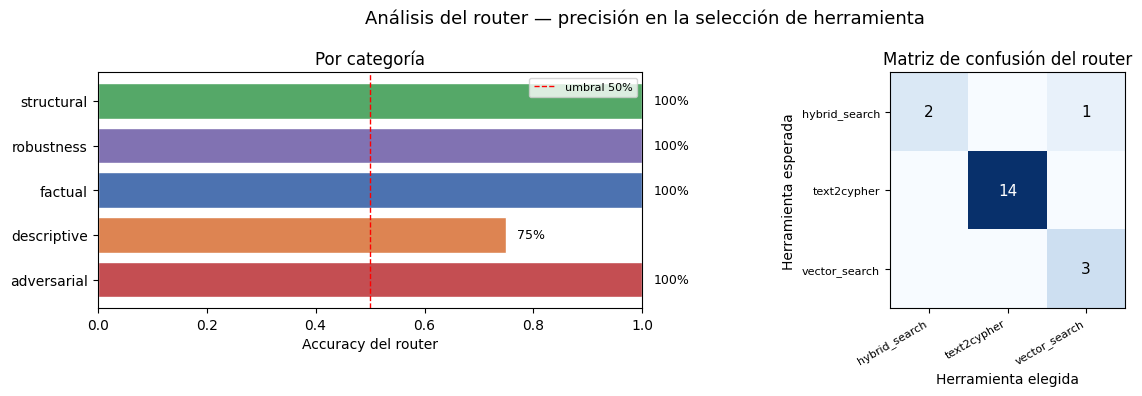

In [5]:
# ── 5.1 Accuracy global y por categoría ──────────────────────────────────────
router_by_cat = scored_df.groupby('category')['routing_correct'].agg(['sum', 'count', 'mean']).rename(
    columns={'sum': 'correct', 'count': 'total', 'mean': 'accuracy'}
).reset_index()

print('Accuracy del router por categoría:')
print(router_by_cat.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Análisis del router — precisión en la selección de herramienta', fontsize=13)

# Barras por categoría
ax = axes[0]
colors = [CATEGORY_COLORS[c] for c in router_by_cat['category']]
bars = ax.barh(router_by_cat['category'], router_by_cat['accuracy'],
               color=colors, edgecolor='white')
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='umbral 50%')
ax.set_xlim(0, 1)
for bar, v in zip(bars, router_by_cat['accuracy']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{v:.0%}', va='center', fontsize=9)
ax.set_xlabel('Accuracy del router')
ax.set_title('Por categoría')
ax.legend(fontsize=8)

# Matriz expected vs actual
all_tools = sorted(set(scored_df['expected_tool'].tolist() + scored_df['actual_tool'].tolist()))
tool_idx  = {t: i for i, t in enumerate(all_tools)}
n = len(all_tools)
matrix = np.zeros((n, n), dtype=int)
for _, row in scored_df.iterrows():
    i = tool_idx.get(row['expected_tool'], 0)
    j = tool_idx.get(row['actual_tool'], 0)
    matrix[i, j] += 1

ax2 = axes[1]
im = ax2.imshow(matrix, cmap='Blues')
ax2.set_xticks(range(n)); ax2.set_yticks(range(n))
ax2.set_xticklabels(all_tools, rotation=30, ha='right', fontsize=8)
ax2.set_yticklabels(all_tools, fontsize=8)
ax2.set_xlabel('Herramienta elegida'); ax2.set_ylabel('Herramienta esperada')
ax2.set_title('Matriz de confusión del router')
for i in range(n):
    for j in range(n):
        if matrix[i, j] > 0:
            ax2.text(j, i, str(matrix[i, j]), ha='center', va='center',
                     fontsize=11, color='white' if matrix[i, j] > matrix.max()/2 else 'black')

plt.tight_layout()
plt.show()

## 6. Métricas RAGAS por categoría

¿Hay categorías donde el pipeline falla sistemáticamente?

Medias RAGAS por categoría:
             context_recall  faithfulness  answer_correctness
category                                                     
adversarial           0.333         1.000               1.000
descriptive           0.500         0.833               0.255
factual               1.000         1.000               1.000
robustness            1.000         1.000               0.833
structural            0.600         0.983               0.999


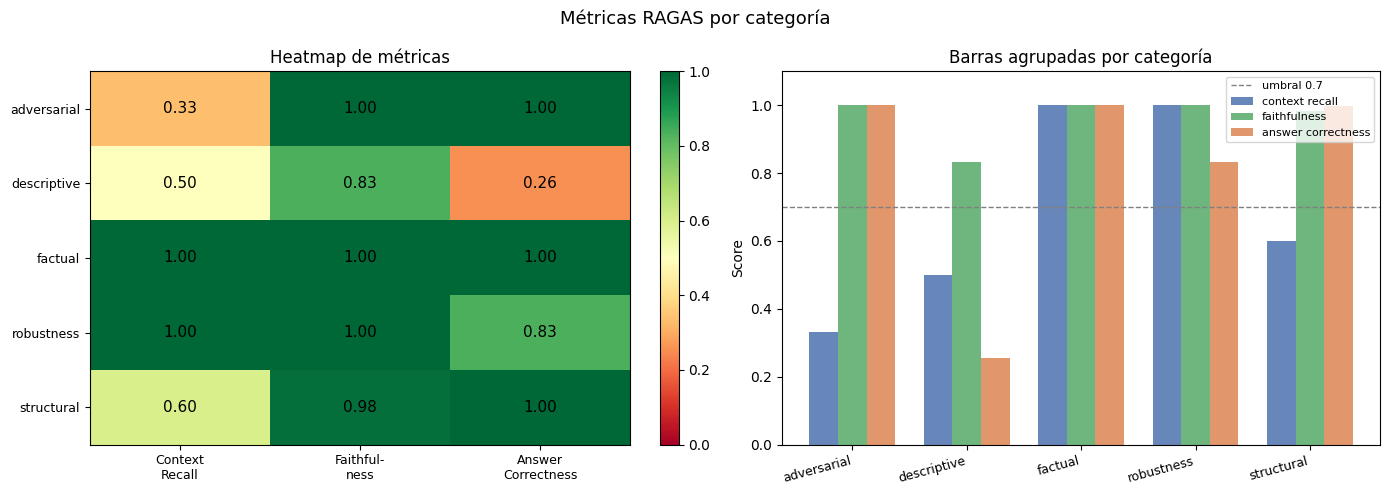

In [6]:
metrics = ['context_recall', 'faithfulness', 'answer_correctness']
cat_metrics = scored_df.groupby('category')[metrics].mean().round(3)
print('Medias RAGAS por categoría:')
print(cat_metrics.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Métricas RAGAS por categoría', fontsize=13)

# Heatmap manual con imshow
ax = axes[0]
data = cat_metrics.values
im = ax.imshow(data, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(['Context\nRecall', 'Faithful-\nness', 'Answer\nCorrectness'], fontsize=9)
ax.set_yticks(range(len(cat_metrics)))
ax.set_yticklabels(cat_metrics.index, fontsize=9)
for i in range(len(cat_metrics)):
    for j in range(len(metrics)):
        ax.text(j, i, f'{data[i, j]:.2f}', ha='center', va='center',
                fontsize=11, color='black')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Heatmap de métricas')

# Gráfico de barras agrupadas
ax2 = axes[1]
cats_order = cat_metrics.index.tolist()
x = np.arange(len(cats_order))
width = 0.25
for k, (metric, color) in enumerate(zip(metrics, ['#4C72B0', '#55A868', '#DD8452'])):
    vals = [cat_metrics.loc[c, metric] for c in cats_order]
    bars = ax2.bar(x + k*width, vals, width, label=metric.replace('_', ' '), color=color, alpha=0.85)
ax2.set_xticks(x + width)
ax2.set_xticklabels(cats_order, rotation=15, ha='right', fontsize=9)
ax2.set_ylim(0, 1.1)
ax2.axhline(0.7, color='gray', linestyle='--', linewidth=1, label='umbral 0.7')
ax2.legend(fontsize=8)
ax2.set_title('Barras agrupadas por categoría')
ax2.set_ylabel('Score')

plt.tight_layout()
plt.show()

## 7. Análisis de latencia

La latencia es un indicador indirecto del tipo de procesamiento: text2cypher implica una llamada LLM para generar el Cypher, mientras que vector_search es más rápido.

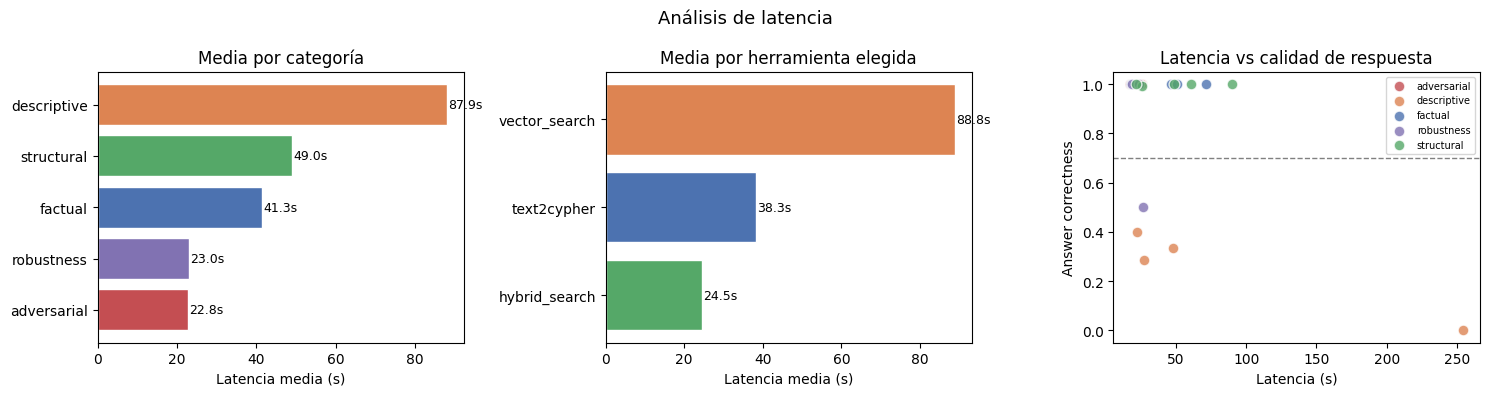


Latencia global — media: 47.1s  mediana: 26.3s  máx: 254.6s


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Análisis de latencia', fontsize=13)

# Por categoría
ax = axes[0]
lat_cat = scored_df.groupby('category')['latency'].mean().sort_values(ascending=True)
colors  = [CATEGORY_COLORS[c] for c in lat_cat.index]
bars = ax.barh(lat_cat.index, lat_cat.values, color=colors, edgecolor='white')
for bar, v in zip(bars, lat_cat.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}s', va='center', fontsize=9)
ax.set_xlabel('Latencia media (s)')
ax.set_title('Media por categoría')

# Por herramienta
ax2 = axes[1]
lat_tool = scored_df.groupby('actual_tool')['latency'].mean().sort_values(ascending=True)
tool_colors = {'text2cypher': '#4C72B0', 'vector_search': '#DD8452',
               'hybrid_search': '#55A868', 'fulltext_search': '#8172B2',
               'greeting': '#BCB8C4', 'out_of_scope': '#BCB8C4', 'skills': '#BCB8C4'}
bars2 = ax2.barh(lat_tool.index,
                 lat_tool.values,
                 color=[tool_colors.get(t, 'gray') for t in lat_tool.index],
                 edgecolor='white')
for bar, v in zip(bars2, lat_tool.values):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{v:.1f}s', va='center', fontsize=9)
ax2.set_xlabel('Latencia media (s)')
ax2.set_title('Media por herramienta elegida')

# Scatter latency vs answer_correctness
ax3 = axes[2]
for cat, grp in scored_df.groupby('category'):
    ax3.scatter(grp['latency'], grp['answer_correctness'],
                color=CATEGORY_COLORS[cat], label=cat, s=60, alpha=0.8, edgecolors='white')
ax3.set_xlabel('Latencia (s)')
ax3.set_ylabel('Answer correctness')
ax3.set_title('Latencia vs calidad de respuesta')
ax3.set_ylim(-0.05, 1.05)
ax3.axhline(0.7, color='gray', linestyle='--', linewidth=1)
ax3.legend(fontsize=7)

plt.tight_layout()
plt.show()

print(f"\nLatencia global — media: {scored_df['latency'].mean():.1f}s  mediana: {scored_df['latency'].median():.1f}s  máx: {scored_df['latency'].max():.1f}s")

## 8. Test de adversarialidad — ¿alucina el sistema?

Para preguntas cuya respuesta **no está en la KB**, el comportamiento correcto es la abstención. Si el sistema responde con datos inventados, tiene un problema de alucinación.

In [8]:
_ABSTENTION_MARKERS = [
    'no se encuentra en la base',
    'not in the knowledge base',
    'not available',
    'outside my scope',
    'fuera de mi ámbito',
    'no tengo información',
    'cannot be determined',
    'no information',
]

def is_abstention(text: str) -> bool:
    t = text.lower()
    return any(m in t for m in _ABSTENTION_MARKERS)

adv_df = scored_df[scored_df['category'] == 'adversarial'].copy()
adv_df['abstained'] = adv_df['answer'].apply(is_abstention)
adv_df['result']    = adv_df['abstained'].map({True: '✓ Abstención correcta', False: '✗ Posible alucinación'})

print('=== Test de adversarialidad ===')
print(adv_df[['id', 'question', 'answer', 'result', 'faithfulness', 'answer_correctness']].to_string(index=False))

abstention_rate = adv_df['abstained'].mean()
print(f'\nTasa de abstención: {abstention_rate:.0%} ({adv_df["abstained"].sum()}/{len(adv_df)})')

# Mostrar respuestas completas de las no-abstenciones
hallucinations = adv_df[~adv_df['abstained']]
if not hallucinations.empty:
    print('\n⚠️  Respuestas potencialmente alucinadas:')
    for _, r in hallucinations.iterrows():
        print(f'  [{r.id}] Q: {r.question}')
        print(f'        A: {r.answer[:200]}')
else:
    print('\n✓ El sistema se abstuvo correctamente en todos los casos adversariales.')

=== Test de adversarialidad ===
id                                                                  question                                                       answer                result  faithfulness  answer_correctness
A1                      What happens in The Adventure of the Blue Carbuncle? Esta información no se encuentra en la base de conocimiento. ✓ Abstención correcta         1.000               1.000
A3 What is the name of Sherlock Holmes' brother who appears in Silver Blaze? Esta información no se encuentra en la base de conocimiento. ✓ Abstención correcta         1.000               1.000
A4                       What year was A Scandal in Bohemia first published? Esta información no se encuentra en la base de conocimiento. ✓ Abstención correcta         1.000               1.000

Tasa de abstención: 100% (3/3)

✓ El sistema se abstuvo correctamente en todos los casos adversariales.


## 9. Test de consistencia — ¿responde igual si reformulo la pregunta?

Un sistema robusto debería dar respuestas equivalentes a paráfrasis de la misma pregunta. Usamos `answer_correctness` con la primera respuesta como ground-truth de las demás.

In [9]:
def run_consistency_test(triplets, rag, neo4j):
    rows = []
    for triplet in tqdm(triplets, desc='Consistencia'):
        topic     = triplet['topic']
        questions = triplet['questions']
        answers   = []
        contexts  = []

        for q in questions:
            rag.reset_conversation()
            try:
                result  = rag.answer(q)
                answer  = result['answer']
                ctx     = result['iterations'][-1].get('retrieval', {}).get('context', []) if result['iterations'] else []
            except Exception:
                answer, ctx = "ERROR", []
            answers.append(answer)
            contexts.append(ctx)
            rows.append({'topic': topic, 'question': q, 'answer': answer, 'context': ctx})

    return pd.DataFrame(rows), answers

consistency_df, _ = run_consistency_test(CONSISTENCY_TRIPLETS, rag, neo4j)
print(f'Consistencia: {len(consistency_df)} respuestas ({len(CONSISTENCY_TRIPLETS)} tópicos × 3 paráfrasis)')

Consistencia:  67%|██████▋   | 2/3 [01:38<00:48, 48.20s/it]Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. db.index.vector.queryNodes is deprecated. It is replaced by SEARCH.', position=<SummaryInputPosition line=2, column=9, offset=9>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 9, 'line': 2, 'column': 9}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\n        CALL db.index.vector.queryNodes('chunk_embeddings', $top_k, $query_embedding)\n        YIELD node AS chunk, score\n        MATCH (s:Story)-[:HAS_CHUNK]->(chunk)\n        \n        RETURN chunk.text AS text,\n               chunk.id AS chunk_id,\n               chunk.chunk_i

Consistencia: 9 respuestas (3 tópicos × 3 paráfrasis)


Scoring consistencia: 100%|██████████| 3/3 [01:00<00:00, 20.27s/it]


Puntuación de consistencia por tópico (1.0 = idéntico semanticamente):
Holmes story appearances   1.000
Stories per collection     1.000
Holmes' method             0.892
Name: consistency_score, dtype: float64


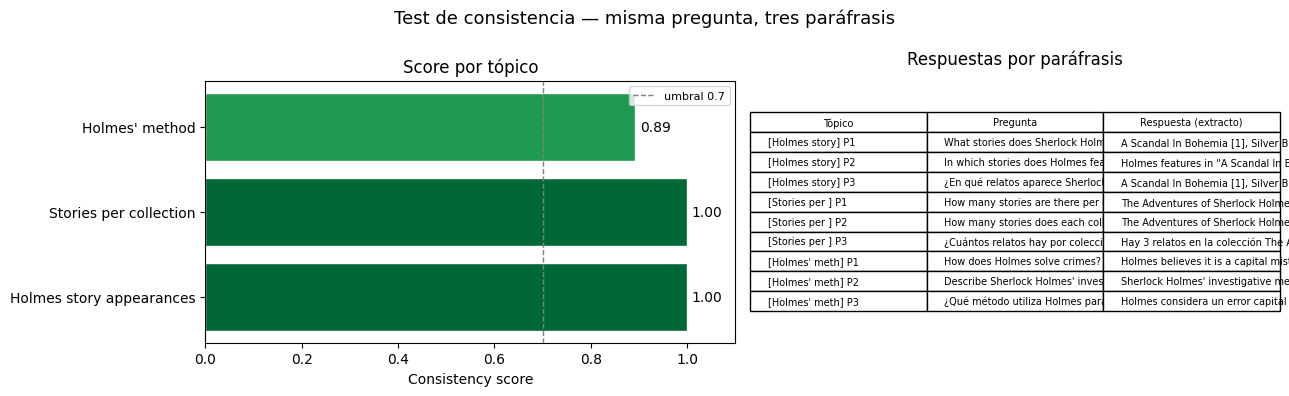

In [10]:
# Puntuar consistencia: answer_correctness(paráfrasis_N, respuesta_1 como GT)
topic_scores = {}

for triplet in tqdm(CONSISTENCY_TRIPLETS, desc='Scoring consistencia'):
    topic = triplet['topic']
    qs    = triplet['questions']
    rows  = consistency_df[consistency_df['topic'] == topic]
    answers = rows['answer'].tolist()
    anchor  = answers[0]  # primera respuesta como referencia

    pair_scores = []
    for i in range(1, len(qs)):
        q_i = qs[i]
        a_i = answers[i] if i < len(answers) else "I don't know"
        s   = evaluator.evaluate_answer_correctness(q_i, a_i, anchor).get('answer_correctness', 0.0)
        pair_scores.append(s)

    topic_scores[topic] = np.mean(pair_scores) if pair_scores else 0.0

consistency_series = pd.Series(topic_scores, name='consistency_score')
print('\nPuntuación de consistencia por tópico (1.0 = idéntico semanticamente):')
print(consistency_series.round(3))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Test de consistencia — misma pregunta, tres paráfrasis', fontsize=13)

ax = axes[0]
colors_c = plt.cm.RdYlGn(consistency_series.values)
bars = ax.barh(list(topic_scores.keys()), list(topic_scores.values()),
               color=colors_c, edgecolor='white')
ax.axvline(0.7, color='gray', linestyle='--', linewidth=1, label='umbral 0.7')
for bar, v in zip(bars, topic_scores.values()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{v:.2f}', va='center', fontsize=10)
ax.set_xlim(0, 1.1)
ax.set_xlabel('Consistency score')
ax.set_title('Score por tópico')
ax.legend(fontsize=8)

# Mostrar las respuestas una al lado de otra
ax2 = axes[1]
ax2.axis('off')
cell_text = []
for triplet in CONSISTENCY_TRIPLETS:
    topic = triplet['topic']
    rows  = consistency_df[consistency_df['topic'] == topic]
    for i, (q, row) in enumerate(zip(triplet['questions'], rows.itertuples())):
        short_q = q[:35] + '…' if len(q) > 35 else q
        short_a = row.answer[:50] + '…' if len(row.answer) > 50 else row.answer
        cell_text.append([f'[{topic[:12]}] P{i+1}', short_q, short_a])

tbl = ax2.table(cellText=cell_text, colLabels=['Tópico', 'Pregunta', 'Respuesta (extracto)'],
                loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(7)
tbl.scale(1, 1.4)
ax2.set_title('Respuestas por paráfrasis', pad=12)

plt.tight_layout()
plt.show()

## 10. Taxonomía de fallos

Clasificamos cada respuesta en cuatro cuadrantes según la combinación de `faithfulness` y `answer_correctness`:

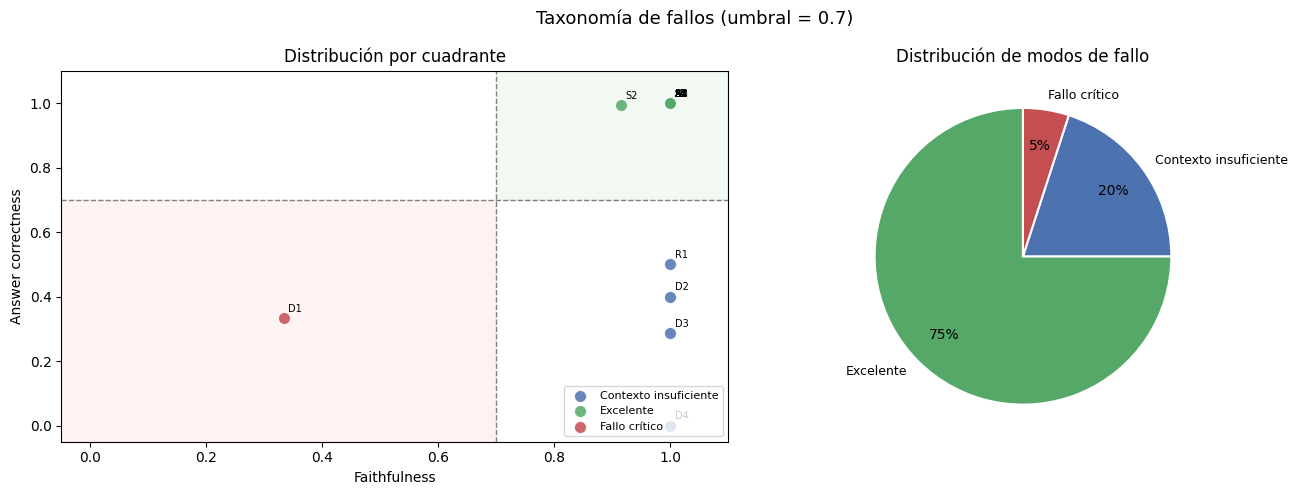


Distribución de modos de fallo:
  Excelente                   : 15 (75%)
  Contexto insuficiente       :  4 (20%)
  Fallo crítico               :  1 (5%)


In [11]:
THRESHOLD = 0.7

def classify_failure(row):
    hi_f = row['faithfulness']       >= THRESHOLD
    hi_c = row['answer_correctness'] >= THRESHOLD
    if hi_f and hi_c:   return 'Excelente'
    if hi_f and not hi_c: return 'Contexto insuficiente'
    if not hi_f and hi_c: return 'Alucinación afortunada'
    return 'Fallo crítico'

scored_df['failure_mode'] = scored_df.apply(classify_failure, axis=1)

mode_counts  = scored_df['failure_mode'].value_counts()
mode_pct     = (mode_counts / len(scored_df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Taxonomía de fallos (umbral = 0.7)', fontsize=13)

# Scatter 2×2
ax = axes[0]
mode_colors = {
    'Excelente':              '#55A868',
    'Contexto insuficiente':  '#4C72B0',
    'Alucinación afortunada': '#DD8452',
    'Fallo crítico':          '#C44E52',
}
for mode, grp in scored_df.groupby('failure_mode'):
    ax.scatter(grp['faithfulness'], grp['answer_correctness'],
               color=mode_colors[mode], label=mode,
               s=80, alpha=0.85, edgecolors='white', zorder=3)
    for _, r in grp.iterrows():
        ax.annotate(r['id'], (r['faithfulness'], r['answer_correctness']),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(3, 3), textcoords='offset points')

ax.axhline(THRESHOLD, color='gray', linestyle='--', linewidth=1)
ax.axvline(THRESHOLD, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Faithfulness')
ax.set_ylabel('Answer correctness')
ax.set_xlim(-0.05, 1.1); ax.set_ylim(-0.05, 1.1)
ax.set_title('Distribución por cuadrante')
ax.legend(fontsize=8, loc='lower right')
ax.fill_between([THRESHOLD, 1.1], THRESHOLD, 1.1, alpha=0.05, color='green')
ax.fill_between([-0.05, THRESHOLD], -0.05, THRESHOLD, alpha=0.05, color='red')

# Torta de distribución
ax2 = axes[1]
colors_pie = [mode_colors[m] for m in mode_counts.index]
wedges, texts, autotexts = ax2.pie(
    mode_counts.values, labels=mode_counts.index,
    colors=colors_pie, autopct='%1.0f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for t in autotexts: t.set_fontsize(10)
for t in texts: t.set_fontsize(9)
ax2.set_title('Distribución de modos de fallo')

plt.tight_layout()
plt.show()

print('\nDistribución de modos de fallo:')
for mode, count in mode_counts.items():
    pct = mode_pct[mode]
    print(f'  {mode:28s}: {count:2d} ({pct:.0f}%)')

## 11. Dashboard ejecutivo

Resumen holístico del sistema en una sola figura: perfil de radar, comparativa por categoría, distribución de fallos y ranking de preguntas más difíciles.

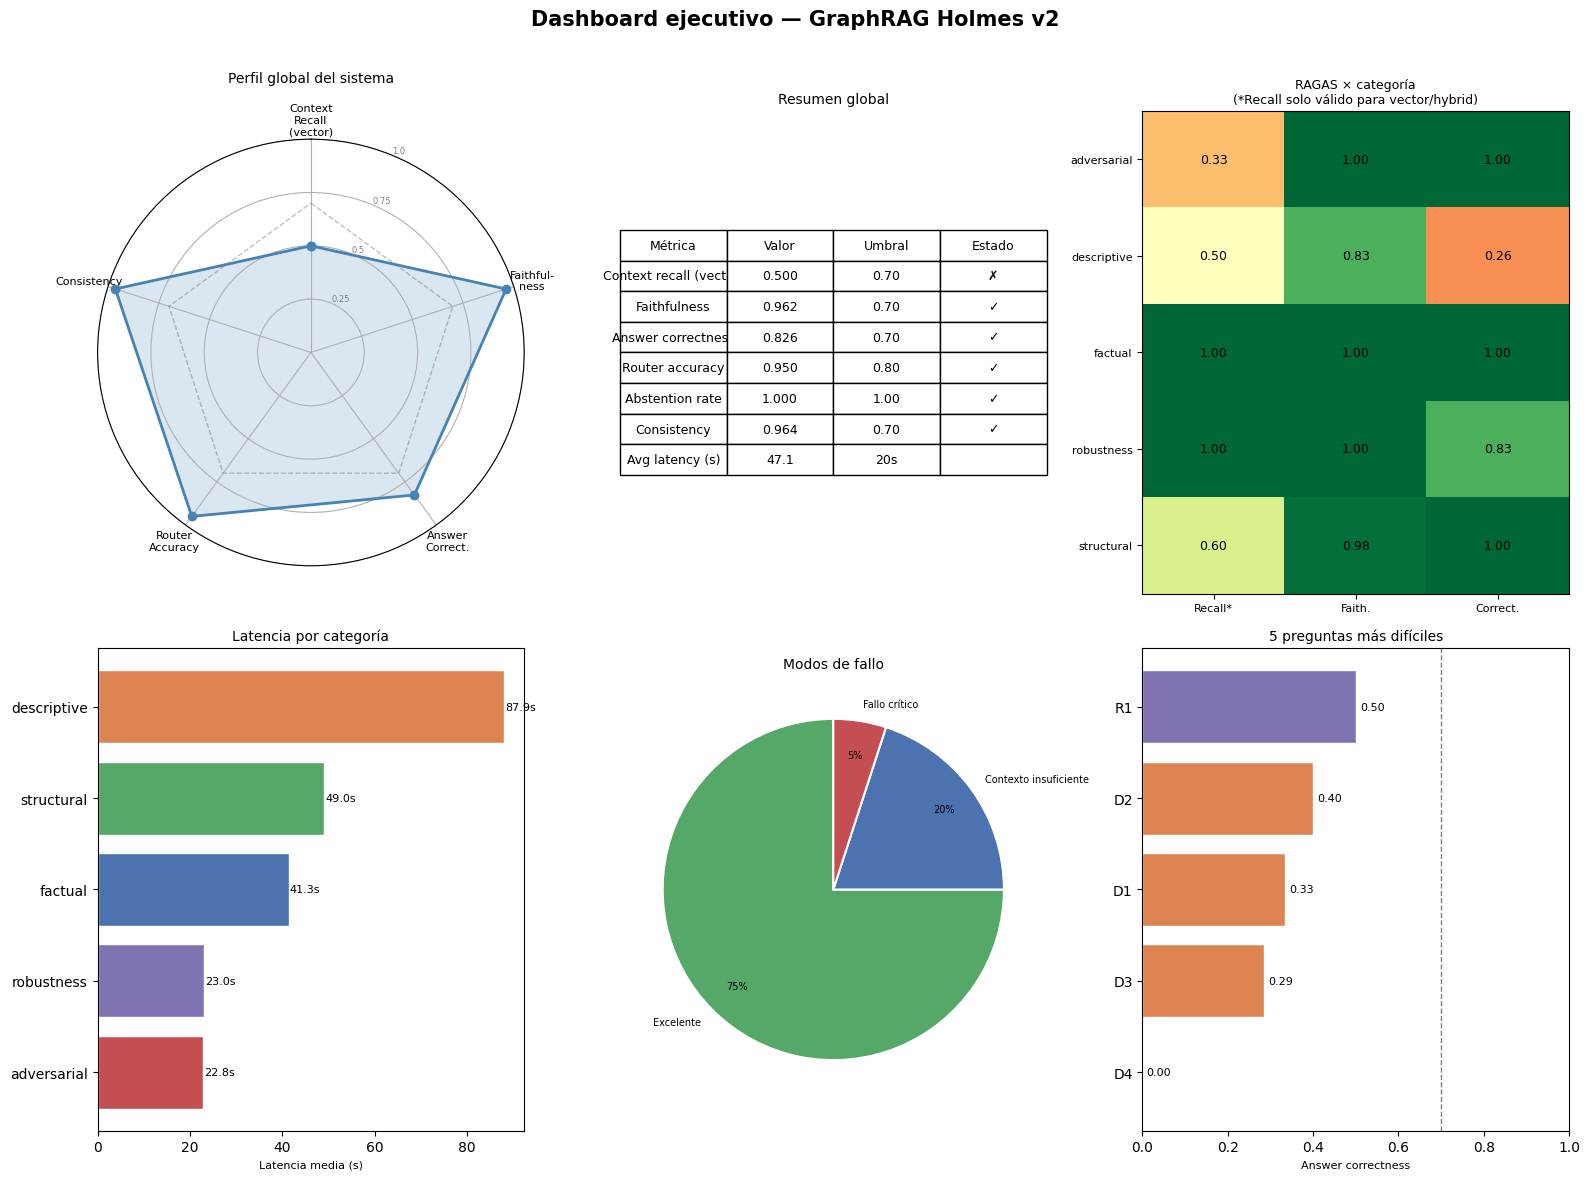

In [12]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard ejecutivo — GraphRAG Holmes v2', fontsize=15, fontweight='bold', y=0.98)

# Context recall solo sobre queries vectoriales (text2cypher no usa chunks)
_vq = scored_df[scored_df['actual_tool'].isin(['vector_search', 'hybrid_search'])]
_recall_value = _vq['context_recall'].mean()

# ── Radar chart (perfil global) ───────────────────────────────────────────────
ax_radar = fig.add_subplot(2, 3, 1, polar=True)
radar_labels = ['Context\nRecall\n(vector)', 'Faithful-\nness', 'Answer\nCorrect.', 'Router\nAccuracy', 'Consistency']
radar_values = [
    _recall_value,
    scored_df['faithfulness'].mean(),
    scored_df['answer_correctness'].mean(),
    scored_df['routing_correct'].mean(),
    consistency_series.mean() if len(consistency_series) > 0 else 0.0,
]
N = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]
radar_values_closed = radar_values + [radar_values[0]]

ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)
ax_radar.plot(angles, radar_values_closed, 'o-', linewidth=2, color='steelblue')
ax_radar.fill(angles, radar_values_closed, alpha=0.2, color='steelblue')
ax_radar.plot(angles, [0.7]*len(angles), '--', linewidth=1, color='gray', alpha=0.5)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(radar_labels, size=8)
ax_radar.set_ylim(0, 1)
ax_radar.set_yticks([0.25, 0.5, 0.75, 1.0])
ax_radar.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], size=6, color='gray')
ax_radar.set_title('Perfil global del sistema', size=10, pad=15)

# ── Tabla de métricas globales ────────────────────────────────────────────────
ax_table = fig.add_subplot(2, 3, 2)
ax_table.axis('off')
_adv = scored_df[scored_df['category'] == 'adversarial'].copy()
_adv['abstained'] = _adv['answer'].apply(is_abstention)
global_metrics = [
    ['Métrica', 'Valor', 'Umbral', 'Estado'],
    ['Context recall (vector)', f"{_recall_value:.3f}",              '0.70', '✓' if _recall_value >= 0.7 else '✗'],
    ['Faithfulness',            f"{scored_df['faithfulness'].mean():.3f}", '0.70', '✓' if scored_df['faithfulness'].mean() >= 0.7 else '✗'],
    ['Answer correctness',      f"{scored_df['answer_correctness'].mean():.3f}", '0.70', '✓' if scored_df['answer_correctness'].mean() >= 0.7 else '✗'],
    ['Router accuracy',         f"{scored_df['routing_correct'].mean():.3f}", '0.80', '✓' if scored_df['routing_correct'].mean() >= 0.8 else '✗'],
    ['Abstention rate',         f"{_adv['abstained'].mean():.3f}",   '1.00', '✓' if _adv['abstained'].mean() >= 0.9 else '✗'],
    ['Consistency',             f"{consistency_series.mean():.3f}",  '0.70', '✓' if consistency_series.mean() >= 0.7 else '✗'],
    ['Avg latency (s)',         f"{scored_df['latency'].mean():.1f}", '20s',  ''],
]
tbl = ax_table.table(cellText=global_metrics[1:], colLabels=global_metrics[0], loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
ax_table.set_title('Resumen global', fontsize=10)

# ── RAGAS por categoría (heatmap) ─────────────────────────────────────────────
ax_heat = fig.add_subplot(2, 3, 3)
data    = cat_metrics.values
im = ax_heat.imshow(data, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax_heat.set_xticks(range(3))
ax_heat.set_xticklabels(['Recall*', 'Faith.', 'Correct.'], fontsize=8)
ax_heat.set_yticks(range(len(cat_metrics)))
ax_heat.set_yticklabels(cat_metrics.index, fontsize=8)
for i in range(len(cat_metrics)):
    for j in range(3):
        ax_heat.text(j, i, f'{data[i, j]:.2f}', ha='center', va='center',
                     fontsize=9, color='black')
ax_heat.set_title('RAGAS × categoría\n(*Recall solo válido para vector/hybrid)', fontsize=9)

# ── Latencia por categoría ────────────────────────────────────────────────────
ax_lat = fig.add_subplot(2, 3, 4)
lat_c   = scored_df.groupby('category')['latency'].mean().sort_values()
bars_l = ax_lat.barh(lat_c.index, lat_c.values,
                     color=[CATEGORY_COLORS[c] for c in lat_c.index], edgecolor='white')
for bar, v in zip(bars_l, lat_c.values):
    ax_lat.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{v:.1f}s', va='center', fontsize=8)
ax_lat.set_xlabel('Latencia media (s)', fontsize=8)
ax_lat.set_title('Latencia por categoría', fontsize=10)

# ── Modos de fallo ────────────────────────────────────────────────────────────
ax_pie = fig.add_subplot(2, 3, 5)
mode_colors = {
    'Excelente':              '#55A868',
    'Contexto insuficiente':  '#4C72B0',
    'Alucinación afortunada': '#DD8452',
    'Fallo crítico':          '#C44E52',
}
mode_counts  = scored_df['failure_mode'].value_counts()
colors_pie2 = [mode_colors[m] for m in mode_counts.index]
ax_pie.pie(mode_counts.values, labels=mode_counts.index, colors=colors_pie2,
           autopct='%1.0f%%', startangle=90, pctdistance=0.8,
           wedgeprops=dict(edgecolor='white', linewidth=1.5),
           textprops={'fontsize': 7})
ax_pie.set_title('Modos de fallo', fontsize=10)

# ── Top 5 preguntas más difíciles ─────────────────────────────────────────────
ax_hard = fig.add_subplot(2, 3, 6)
hard = scored_df.nsmallest(5, 'answer_correctness')[['id', 'category', 'answer_correctness']]
colors_h = [CATEGORY_COLORS[c] for c in hard['category']]
bars_h = ax_hard.barh(hard['id'], hard['answer_correctness'], color=colors_h, edgecolor='white')
for bar, v in zip(bars_h, hard['answer_correctness']):
    ax_hard.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.2f}', va='center', fontsize=8)
ax_hard.set_xlim(0, 1)
ax_hard.axvline(0.7, color='gray', linestyle='--', linewidth=1)
ax_hard.set_xlabel('Answer correctness', fontsize=8)
ax_hard.set_title('5 preguntas más difíciles', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 12. Conclusiones y recomendaciones

### Lectura de resultados

A continuación se generan conclusiones automáticas basadas en los datos del benchmark.

In [13]:
print('═' * 60)
print('  INFORME DE EVALUACIÓN — GraphRAG Holmes')
print('═' * 60)

# Context recall solo sobre queries que usan retrieval vectorial.
# Para text2cypher el "contexto" son resultados del grafo, no chunks;
# incluirlos en la media global produce un 0 artificial por diseño.
_vector_queries = scored_df[scored_df['actual_tool'].isin(['vector_search', 'hybrid_search'])]
global_recall = _vector_queries['context_recall'].mean()

global_faith  = scored_df['faithfulness'].mean()
global_corr   = scored_df['answer_correctness'].mean()
router_acc    = scored_df['routing_correct'].mean()
adv_mask      = scored_df['category'] == 'adversarial'
adv_df_local  = scored_df[adv_mask].copy()
adv_df_local['abstained'] = adv_df_local['answer'].apply(is_abstention)
abst_rate     = adv_df_local['abstained'].mean()
consist_avg   = consistency_series.mean()

print(f'\n📊 MÉTRICAS GLOBALES')
print(f'  Context recall (vector/hybrid) : {global_recall:.3f}  [{len(_vector_queries)} queries]')
print(f'  Faithfulness                   : {global_faith:.3f}')
print(f'  Answer correctness             : {global_corr:.3f}')
print(f'  Router accuracy                : {router_acc:.3f}')
print(f'  Abstención (adversarial)       : {abst_rate:.3f}')
print(f'  Consistencia                   : {consist_avg:.3f}')
print(f'  Latencia media                 : {scored_df["latency"].mean():.1f}s')

print(f'\n✅ FORTALEZAS')
best_cat = cat_metrics['answer_correctness'].idxmax()
if global_faith >= 0.85:
    print(f'  · Alta fidelidad ({global_faith:.2f}): el sistema raramente alucina cuando tiene contexto.')
if abst_rate >= 0.75:
    print(f'  · Buena abstención ({abst_rate:.0%}): el sistema sabe decir "no sé" en preguntas adversariales.')
if router_acc >= 0.7:
    print(f'  · Router estable ({router_acc:.0%}): selecciona la herramienta correcta en la mayoría de los casos.')
print(f'  · Mejor categoría: {best_cat} (correctness={cat_metrics.loc[best_cat, "answer_correctness"]:.2f})')

print(f'\n⚠️  DEBILIDADES')
worst_cat = cat_metrics['answer_correctness'].idxmin()
if global_recall < 0.7:
    print(f'  · Context recall bajo ({global_recall:.2f}) en queries vectoriales: los retrievers no siempre encuentran los chunks relevantes.')
if consist_avg < 0.7:
    print(f'  · Baja consistencia ({consist_avg:.2f}): reformular la misma pregunta da respuestas diferentes.')
if router_acc < 0.8:
    print(f'  · Router impreciso ({router_acc:.0%}): hay ruido en la selección de herramienta.')
print(f'  · Peor categoría: {worst_cat} (correctness={cat_metrics.loc[worst_cat, "answer_correctness"]:.2f})')

print(f'\n🔧 RECOMENDACIONES PRIORIZADAS')
recs = []
if global_recall < 0.7:
    recs.append('1. Aumentar top_k_results o ajustar chunk_size para mejorar context recall en queries vectoriales.')
if router_acc < 0.8:
    recs.append('2. Añadir ejemplos few-shot al prompt del router para los tipos de pregunta fallidos.')
if consist_avg < 0.7:
    recs.append('3. Investigar por qué cambia la respuesta al reformular — posible problema de anáfora.')
if abst_rate < 1.0:
    recs.append('4. Reforzar el prompt de generación para que sea más conservador con datos fuera de la KB.')
if not recs:
    recs.append('El sistema supera los umbrales en todas las dimensiones evaluadas. Considerar ampliar el corpus.')
for r in recs:
    print(f'  {r}')

print('\n' + '═' * 60)

════════════════════════════════════════════════════════════
  INFORME DE EVALUACIÓN — GraphRAG Holmes
════════════════════════════════════════════════════════════

📊 MÉTRICAS GLOBALES
  Context recall (vector/hybrid) : 0.500  [6 queries]
  Faithfulness                   : 0.962
  Answer correctness             : 0.826
  Router accuracy                : 0.950
  Abstención (adversarial)       : 1.000
  Consistencia                   : 0.964
  Latencia media                 : 47.1s

✅ FORTALEZAS
  · Alta fidelidad (0.96): el sistema raramente alucina cuando tiene contexto.
  · Buena abstención (100%): el sistema sabe decir "no sé" en preguntas adversariales.
  · Router estable (95%): selecciona la herramienta correcta en la mayoría de los casos.
  · Mejor categoría: adversarial (correctness=1.00)

⚠️  DEBILIDADES
  · Context recall bajo (0.50) en queries vectoriales: los retrievers no siempre encuentran los chunks relevantes.
  · Peor categoría: descriptive (correctness=0.26)

🔧 RECOMEND

## 13. GraphRAG vs Plain RAG — valor añadido del grafo

La hipótesis central del proyecto: combinar grafo de conocimiento con búsqueda vectorial supera a un RAG tradicional. Esta sección lo demuestra empíricamente para las preguntas **factuales y estructurales**, donde la respuesta requiere contar, agregar o hacer traversal multi-salto — operaciones que el grafo domina pero el texto plano no puede resolver.

> **Metodología**: se ejecutan las mismas preguntas con `VectorRetriever` puro (sin graph traversal) y se compara el `answer_correctness` con el del sistema completo.

In [14]:
from graphrag.retrieval import VectorRetriever
from graphrag.llm.gemini_client import GeminiClient, ModelTier

_PLAIN_RAG_SYSTEM = (
    "You are a concise question-answering assistant specialized in Sherlock Holmes stories. "
    "Answer ONLY from the provided context. If the context does not contain the answer, "
    "reply exactly: 'Esta información no se encuentra en la base de conocimiento.' "
    "Keep the answer short: one to three sentences maximum. "
    "Answer in the same language as the question."
)


def plain_rag_answer(question, neo4j, top_k=5):
    """RAG puro: solo vector search sobre chunks. Sin traversal del grafo."""
    results = VectorRetriever(neo4j).retrieve(question, top_k=top_k)
    context = [r["text"] for r in results]
    if not context:
        return "Esta información no se encuentra en la base de conocimiento.", []
    ctx_str = "\n\n".join(f"[{i+1}] {chunk}" for i, chunk in enumerate(context))
    answer  = GeminiClient().generate(
        prompt=f"Context:\n{ctx_str}\n\nQuestion: {question}",
        model_tier=ModelTier.FLASH,
        system_instruction=_PLAIN_RAG_SYSTEM,
        temperature=0.0,
    )
    return answer, context


# Solo las categorías donde el grafo marca diferencia real
GRAPH_SENSITIVE = ["factual", "structural"]
subset = benchmark_df[benchmark_df["category"].isin(GRAPH_SENSITIVE)].copy()

plain_answers, plain_contexts = [], []
for _, row in tqdm(subset.iterrows(), total=len(subset), desc="Plain RAG"):
    ans, ctx = plain_rag_answer(row["question"], neo4j)
    plain_answers.append(ans)
    plain_contexts.append(ctx)

subset["plain_answer"]  = plain_answers
subset["plain_context"] = plain_contexts

print(f"Plain RAG ejecutado para {len(subset)} preguntas")
for _, r in subset.iterrows():
    print(f"\n[{r['id']}] {r['question']}")
    print(f"  GraphRAG : {str(r['answer'])[:120]}")
    print(f"  Plain RAG: {str(r['plain_answer'])[:120]}")


Plain RAG: 100%|██████████| 10/10 [08:08<00:00, 48.83s/it]

Plain RAG ejecutado para 10 preguntas

[F1] How many stories are in the graph?
  GraphRAG : 6 [1].
  Plain RAG: Esta información no se encuentra en la base de conocimiento.

[F2] Which characters appear in more than one story?
  GraphRAG : Sherlock Holmes [1], Watson [2], and Mrs. Hudson [3] appear in more than one story.
  Plain RAG: Sherlock Holmes and Dr. Watson appear in more than one story.

[F3] How many deductions does Holmes make in The Adventure of the Speckled Band?
  GraphRAG : 77 [1].
  Plain RAG: Holmes makes several deductions in "The Adventure of the Speckled Band." He deduces that the danger did not come from th

[F4] Which story has the most deductions?
  GraphRAG : The Adventure Of The Speckled Band has the most deductions with 77 [1]. Other stories and their deduction counts are: Si
  Plain RAG: Esta información no se encuentra en la base de conocimiento.

[S1] Which characters know Holmes AND appear in more than one story?
  GraphRAG : Esta información no se encuent

Scoring Plain RAG: 100%|██████████| 10/10 [02:36<00:00, 15.66s/it]


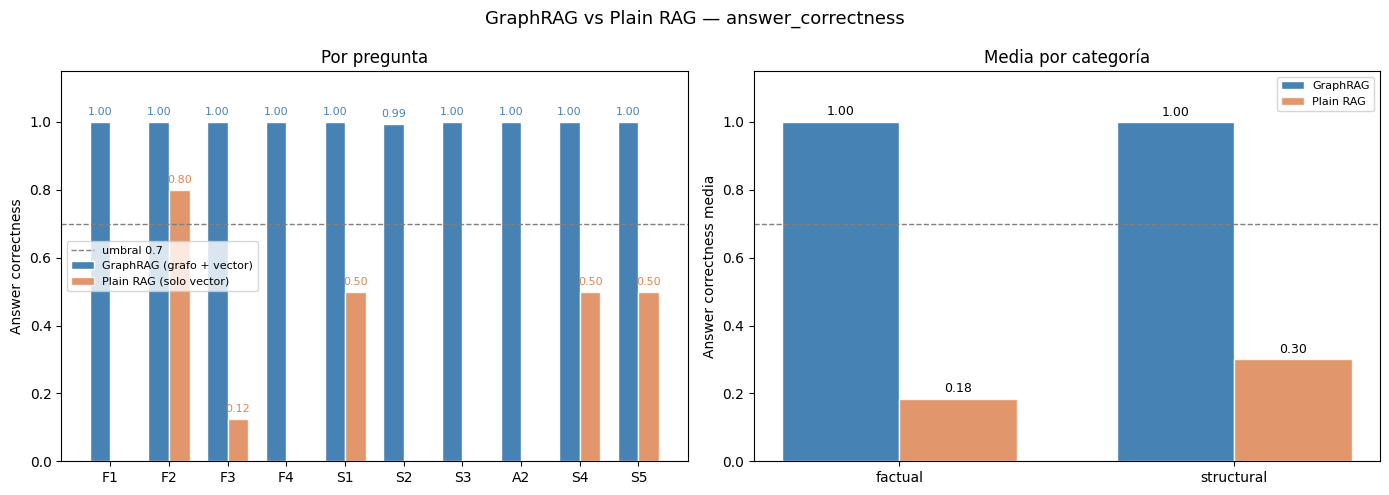


=== GraphRAG vs Plain RAG ===
GraphRAG  correctness media : 0.999
Plain RAG correctness media : 0.242
Ganancia del grafo (Δ)      : +0.757

  [F1] ↑  GraphRAG=1.00  PlainRAG=0.00  Δ=+1.00  How many stories are in the graph?
  [F2] ↑  GraphRAG=1.00  PlainRAG=0.80  Δ=+0.20  Which characters appear in more than one story?
  [F3] ↑  GraphRAG=1.00  PlainRAG=0.12  Δ=+0.88  How many deductions does Holmes make in The Adventure o
  [F4] ↑  GraphRAG=1.00  PlainRAG=0.00  Δ=+1.00  Which story has the most deductions?
  [S1] ↑  GraphRAG=1.00  PlainRAG=0.50  Δ=+0.50  Which characters know Holmes AND appear in more than on
  [S2] ↑  GraphRAG=0.99  PlainRAG=0.00  Δ=+0.99  What objects does Sherlock Holmes use across all storie
  [S3] ↑  GraphRAG=1.00  PlainRAG=0.00  Δ=+1.00  In which stories do crimes of type murder appear?
  [A2] ↑  GraphRAG=1.00  PlainRAG=0.00  Δ=+1.00  How old is Irene Adler?
  [S4] ↑  GraphRAG=1.00  PlainRAG=0.50  Δ=+0.50  What deduction chain does Holmes build in The Red-Heade


In [15]:
 # Scoring Plain RAG con answer_correctness
plain_corr = []
for _, row in tqdm(subset.iterrows(), total=len(subset), desc="Scoring Plain RAG"):
    ctx = row["plain_context"] if isinstance(row["plain_context"], list) else []
    ans = str(row["plain_answer"]) if row["plain_answer"] else "I don't know"
    gt  = str(row["ground_truth"])
    s = evaluator.evaluate_answer_correctness(row["question"], ans, gt).get("answer_correctness", 0.0)
    plain_corr.append(s)

subset = subset.copy()
subset["plain_correctness"]    = plain_corr
subset["graphrag_correctness"] = [
    scored_df.loc[scored_df["id"] == rid, "answer_correctness"].values[0]
    for rid in subset["id"]
]

# ── Gráfico comparativo ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("GraphRAG vs Plain RAG — answer_correctness", fontsize=13)

ids   = subset["id"].tolist()
x     = np.arange(len(ids))
width = 0.35

ax = axes[0]
b1 = ax.bar(x - width/2, subset["graphrag_correctness"], width,
            label="GraphRAG (grafo + vector)", color="steelblue", edgecolor="white")
b2 = ax.bar(x + width/2, subset["plain_correctness"], width,
            label="Plain RAG (solo vector)", color="#DD8452", edgecolor="white", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(ids, fontsize=10)
ax.set_ylim(0, 1.15)
ax.axhline(0.7, color="gray", linestyle="--", linewidth=1, label="umbral 0.7")
ax.set_ylabel("Answer correctness")
ax.set_title("Por pregunta")
ax.legend(fontsize=8)
for bar in b1:
    if bar.get_height() > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.2f}", ha="center", fontsize=8, color="steelblue")
for bar in b2:
    if bar.get_height() > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.2f}", ha="center", fontsize=8, color="#DD8452")

# Medias por categoría
ax2 = axes[1]
comp = subset.groupby("category")[["graphrag_correctness", "plain_correctness"]].mean()
x2   = np.arange(len(comp))
b3 = ax2.bar(x2 - width/2, comp["graphrag_correctness"], width,
             label="GraphRAG", color="steelblue", edgecolor="white")
b4 = ax2.bar(x2 + width/2, comp["plain_correctness"], width,
             label="Plain RAG", color="#DD8452", edgecolor="white", alpha=0.85)
ax2.set_xticks(x2)
ax2.set_xticklabels(comp.index, fontsize=10)
ax2.set_ylim(0, 1.15)
ax2.axhline(0.7, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Answer correctness media")
ax2.set_title("Media por categoría")
ax2.legend(fontsize=8)
for bars in [b3, b4]:
    for bar in bars:
        if bar.get_height() > 0.01:
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f"{bar.get_height():.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# Resumen cuantitativo
delta = subset["graphrag_correctness"].mean() - subset["plain_correctness"].mean()
print("\n=== GraphRAG vs Plain RAG ===")
print(f"GraphRAG  correctness media : {subset['graphrag_correctness'].mean():.3f}")
print(f"Plain RAG correctness media : {subset['plain_correctness'].mean():.3f}")
print(f"Ganancia del grafo (Δ)      : {delta:+.3f}")
print()
for _, row in subset.iterrows():
    d    = row["graphrag_correctness"] - row["plain_correctness"]
    icon = "↑" if d > 0.1 else ("↓" if d < -0.1 else "=")
    print(f"  [{row['id']}] {icon}  GraphRAG={row['graphrag_correctness']:.2f}  "
          f"PlainRAG={row['plain_correctness']:.2f}  Δ={d:+.2f}  "
          f"{row['question'][:55]}")


## 16. Guardar resultados

In [16]:
from datetime import datetime

ts = datetime.now().strftime('%Y%m%d_%H%M%S')
out_path = f'../data/evaluation_v2_{ts}.csv'

# Guardar benchmark principal (sin la columna 'context' que es lista)
export_cols = [c for c in scored_df.columns if c != 'context']
scored_df[export_cols].to_csv(out_path, index=False)
print(f'Resultados guardados: {out_path}')

# Guardar consistencia
consist_path = f'../data/consistency_{ts}.csv'
consistency_df[['topic', 'question', 'answer']].to_csv(consist_path, index=False)
print(f'Consistencia guardada: {consist_path}')

neo4j.close()
print('Conexión cerrada.')

Resultados guardados: ../data/evaluation_v2_20260507_233843.csv
Consistencia guardada: ../data/consistency_20260507_233843.csv
Conexión cerrada.
